# Para abordar este proyecto de análisis de datos de la empresa Y.Afisha, seguiremos los siguientes pasos:


# Introducción

La empresa Y.Afisha, conocida por su plataforma de ventas en línea, busca optimizar sus gastos de marketing y mejorar la eficiencia de sus campañas publicitarias. Como parte del equipo analítico, nuestra misión es analizar los datos de visitas, pedidos y gastos de marketing desde enero de 2017 hasta diciembre de 2018. Con esta información, nuestro objetivo es responder a preguntas clave sobre el comportamiento de los usuarios, la efectividad de las campañas publicitarias y la rentabilidad de las inversiones en marketing.

En este proyecto, vamos a explorar los siguientes aspectos:

Comportamiento de los usuarios:

- ¿Cuántas personas utilizan el servicio diariamente, semanalmente y mensualmente?
- ¿Cuántas sesiones se generan por día?
- ¿Cuál es la duración de cada sesión?
- ¿Con qué frecuencia regresan los usuarios?


Patrones de ventas:

- ¿Cuándo empiezan los usuarios a comprar después de registrarse?
- ¿Cuántos pedidos realizan en un periodo determinado?
- ¿Cuál es el tamaño promedio de las compras?
- ¿Cuál es el valor de vida del cliente (LTV)?


Eficiencia del marketing:

- ¿Cuánto dinero se ha gastado en marketing en total, por fuente de adquisición y a lo largo del tiempo?
- ¿Cuál es el costo de adquisición de clientes (CAC) por cada fuente de adquisición?
- ¿Qué tan rentables han sido las inversiones en marketing (ROMI)?

A través de un análisis detallado de estos datos, generaremos informes y gráficos que nos permitirán comprender mejor el comportamiento de los clientes y la eficacia de las estrategias de marketing. Finalmente, proporcionaremos recomendaciones fundamentadas sobre cómo optimizar las inversiones en marketing, identificando las fuentes y plataformas más efectivas para maximizar el retorno de inversión (ROI).

Nuestro enfoque metodológico se centrará en la preparación de datos, el cálculo de métricas clave y la interpretación de resultados. Este análisis ayudará a Y.Afisha a tomar decisiones informadas y estratégicas para mejorar sus esfuerzos de marketing y aumentar la rentabilidad del negocio.

Estructura del Proyecto

El proyecto se dividirá en los siguientes pasos:

- Descarga y preparación de datos: Cargar los datasets de visitas, pedidos y gastos de marketing, asegurándonos de que los datos estén en el formato adecuado para el análisis.
- Cálculo de métricas e informes: Analizar el comportamiento de los usuarios, patrones de ventas y eficiencia del marketing mediante el cálculo de diversas métricas y la visualización de los datos.
- Conclusiones y recomendaciones: Interpretar los resultados y proporcionar recomendaciones sobre las mejores estrategias de marketing basadas en los hallazgos del análisis.

Al seguir esta estructura, garantizaremos un análisis exhaustivo y coherente que ayudará a Y.Afisha a optimizar sus estrategias de marketing y mejorar la rentabilidad del negocio.

# Inicialización

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Paso: Descargar los datos y prepárarlos para el análisis.

In [2]:
# Cargar los datos
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

# Verificar la información de los datasets
visits.info()
orders.info()
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 

# Observaciones para la muestras de datos

Después de cargar y revisar la información de los datasets de visitas, pedidos y gastos de marketing, hemos obtenido una visión general de su estructura y contenido. A continuación, se presentan las conclusiones basadas en los resultados obtenidos:

Dataset de Visitas: Cantidad de registros 359,400 entradas, 5 columnas que incluyen Device, End Ts, Source Id, Start Ts, y Uid.

Tipos de datos:

- Device: Almacena el dispositivo del usuario (tipo object).
- End Ts y Start Ts: Almacenan la fecha y hora de inicio y término de la sesión (tipo object).
- Source Id: Almacena el identificador de la fuente de anuncios (tipo int64).
- Uid: Almacena el identificador único del usuario (tipo uint64).

Conclusión: Los datos de visitas parecen estar completos y sin valores nulos. Sin embargo, es necesario convertir las columnas de fecha y hora (Start Ts y End Ts) al tipo datetime para facilitar el análisis temporal y la columna Device a category para mejorar la eficiencia de memoria y rendimiento.

Dataset de Pedidos: Cantidad de registros 50,415 entradas, 3 columnas que incluyen Buy Ts, Revenue, y Uid.

Tipos de datos:

- Buy Ts: Almacena la fecha y hora del pedido (tipo object).
- Revenue: Almacena los ingresos generados por el pedido (tipo float64).
- Uid: Almacena el identificador único del usuario (tipo uint64).

Conclusión: Los datos de pedidos también están completos y sin valores nulos. Es necesario convertir la columna Buy Ts al tipo datetime para realizar análisis temporales precisos.

Dataset de Costos: Cantidad de registros 2,542 entradas, 3 columnas que incluyen source_id, dt, y costs.

Tipos de datos:

- source_id: Almacena el identificador de la fuente de anuncios (tipo int64).
- dt: Almacena la fecha del gasto (tipo object).
- costs: Almacena los gastos en la fuente de anuncios para ese día (tipo float64).

Conclusión: Los datos de costos están completos y sin valores nulos. Es necesario convertir la columna dt al tipo datetime para realizar análisis temporales.

Acciones a Realizar

Conversión de columnas de fecha y hora: Convertiremos las columnas Start Ts, End Ts (en visitas), Buy Ts (en pedidos), y dt (en costos) al tipo datetime.

Conversión de columna Device a category (en visitas).

Una vez convertidos los tipos de datos, continuaremos con la revision de datos para proceder con el análisis detallado para calcular las métricas requeridas y responder a las preguntas planteadas.

In [3]:
# Cargar los datos cambiando el Dtype 
visits = pd.read_csv(
    '/datasets/visits_log_us.csv',
    dtype={'Device': 'category'},
    parse_dates=['Start Ts', 'End Ts'],
)
orders = pd.read_csv(
    '/datasets/orders_log_us.csv',
    parse_dates=['Buy Ts']
)
costs = pd.read_csv(
    '/datasets/costs_us.csv',
    parse_dates=['dt']
)

In [4]:
# Convertir nombres de columnas a snake_case
visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')
costs.columns = costs.columns.str.lower().str.replace(' ', '_')

In [5]:
# Imprime la informacion general/resumida sobre el df visits
visits.info()
display(visits.head())
visits.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


0

In [6]:
# Imprime la informacion general/resumida sobre el df orders
orders.info()
display(orders.head())
orders.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


0

In [7]:
# Imprime la informacion general/resumida sobre el df costs
costs.info()
display(costs.head())
costs.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


0

Una vez convertidos los tipos de datos y confirmado que no tenemos datos duplicados podemos continuar a proceder con el análisis detallado para calcular las métricas requeridas y responder a las preguntas planteadas.

## Paso. Informes y Métricas

# Visitas

In [8]:
# ¿Cuántas personas lo usan cada día, semana y mes?

# Crear nuevas columnas para día, semana y mes
visits['day'] = visits['start_ts'].dt.date
visits['week'] = visits['start_ts'].dt.to_period('W').apply(lambda r: r.start_time)
visits['month'] = visits['start_ts'].dt.to_period('M').apply(lambda r: r.start_time)

# Usuarios únicos por día, semana y mes
users_per_day = visits.groupby('day')['uid'].nunique()
users_per_week = visits.groupby(pd.Grouper(key='start_ts', freq='W'))['uid'].nunique()
users_per_month = visits.groupby(pd.Grouper(key='start_ts', freq='M'))['uid'].nunique()

# Mostrar resultados
print(users_per_day.head())
print(users_per_week.head())
print(users_per_month.head())

day
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: uid, dtype: int64
start_ts
2017-06-04    2021
2017-06-11    4129
2017-06-18    2812
2017-06-25    2878
2017-07-02    3064
Freq: W-SUN, Name: uid, dtype: int64
start_ts
2017-06-30    13259
2017-07-31    14183
2017-08-31    11631
2017-09-30    18975
2017-10-31    29692
Freq: M, Name: uid, dtype: int64


In [9]:
# ¿Cuántas sesiones hay por día?

# Sesiones por día
sessions_per_day = visits.groupby('day')['uid'].count()

# Mostrar resultados
sessions_per_day

day
2017-06-01     664
2017-06-02     658
2017-06-03     477
2017-06-04     510
2017-06-05     893
              ... 
2018-05-27     672
2018-05-28    1156
2018-05-29    1035
2018-05-30    1410
2018-05-31    2256
Name: uid, Length: 364, dtype: int64

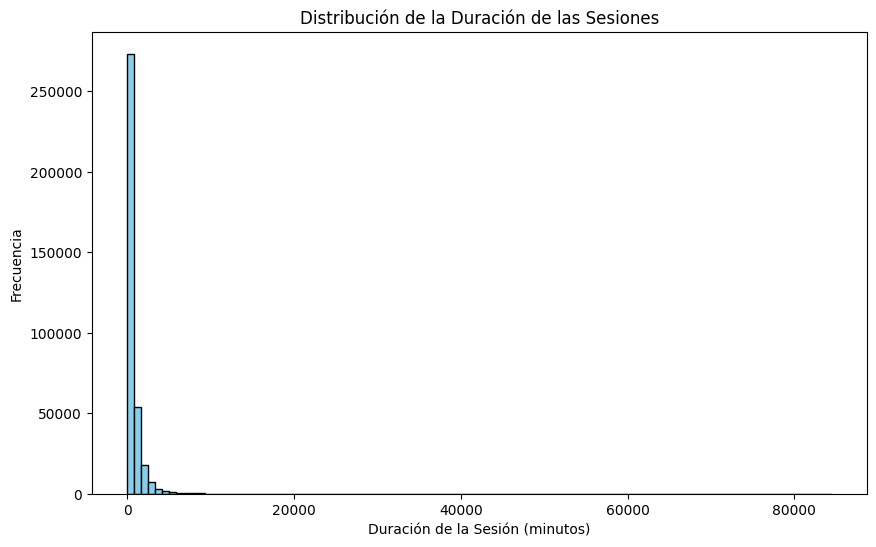

In [10]:
#¿Cuál es la duración de cada sesión?

# Calcular la duración de la sesión en segundos
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

# Duración promedio de la sesión
average_session_duration = visits['session_duration'].mean()

# Mostrar resultado
average_session_duration

# Crear histograma de la duración de las sesiones
plt.figure(figsize=(10, 6))
plt.hist(visits['session_duration'], bins=100, color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de las Sesiones')
plt.xlabel('Duración de la Sesión (minutos)')
plt.ylabel('Frecuencia')
plt.grid(False)
plt.show()

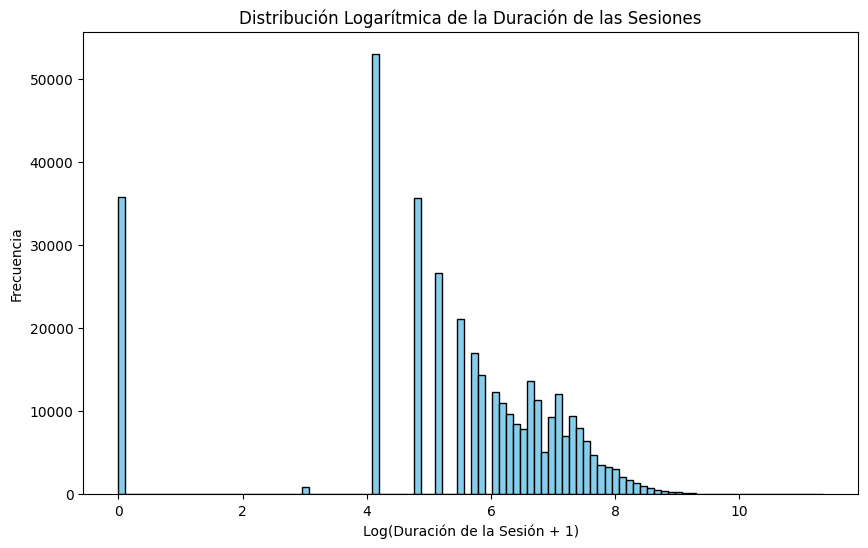

In [11]:
# Aplicar la transformación logarítmica a la duración de las sesiones
visits['log_session_duration'] = np.log1p(visits['session_duration'])

# Crear un histograma de la duración de las sesiones transformada
plt.figure(figsize=(10, 6))
plt.hist(visits['log_session_duration'], bins=100, color='skyblue', edgecolor='black')
plt.title('Distribución Logarítmica de la Duración de las Sesiones')
plt.xlabel('Log(Duración de la Sesión + 1)')
plt.ylabel('Frecuencia')
plt.grid(False)
plt.show()

In [12]:
#¿Con qué frecuencia los usuarios regresan?

# Frecuencia de retorno de usuarios
returning_users = visits.groupby('uid')['day'].nunique().value_counts()

# Mostrar resultado
returning_users

1      183124
2       27591
3        8484
4        3706
5        1821
        ...  
54          1
58          1
62          1
66          1
121         1
Name: day, Length: 115, dtype: int64

In [13]:
# Obtener la fecha de la primera visita de cada usuario:
first_visits = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()

first_visits['first_visit_month'] = first_visits['start_ts'].dt.to_period('M').dt.start_time

# Crear la columna del mes de la visita en la tabla visits:
visits['session_month'] = visits['start_ts'].dt.to_period('M').dt.start_time

# Combinar las tablas visits y first_visits:
visits_full = visits.merge(first_visits[['uid', 'first_visit_month']], on='uid', how='left')

# Calcular la diferencia en meses (age_months):
visits_full['age_months'] = ((visits_full['session_month'] - visits_full['first_visit_month']) / np.timedelta64(1, 'M')).round().astype(int)

# Crear una tabla de cohortes:
cohorts = visits_full.pivot_table(index='first_visit_month',
                                  columns='age_months',
                                  values='uid',
                                  aggfunc='nunique')

cohorts

age_months,0,1,2,3,4,5,6,7,8,9,10,11
first_visit_month,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,NaN
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,NaN,NaN
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,NaN,NaN,NaN
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,NaN,NaN,NaN,NaN
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,NaN,NaN,NaN,NaN,NaN
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,22197.0,1267.0,565.0,446.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


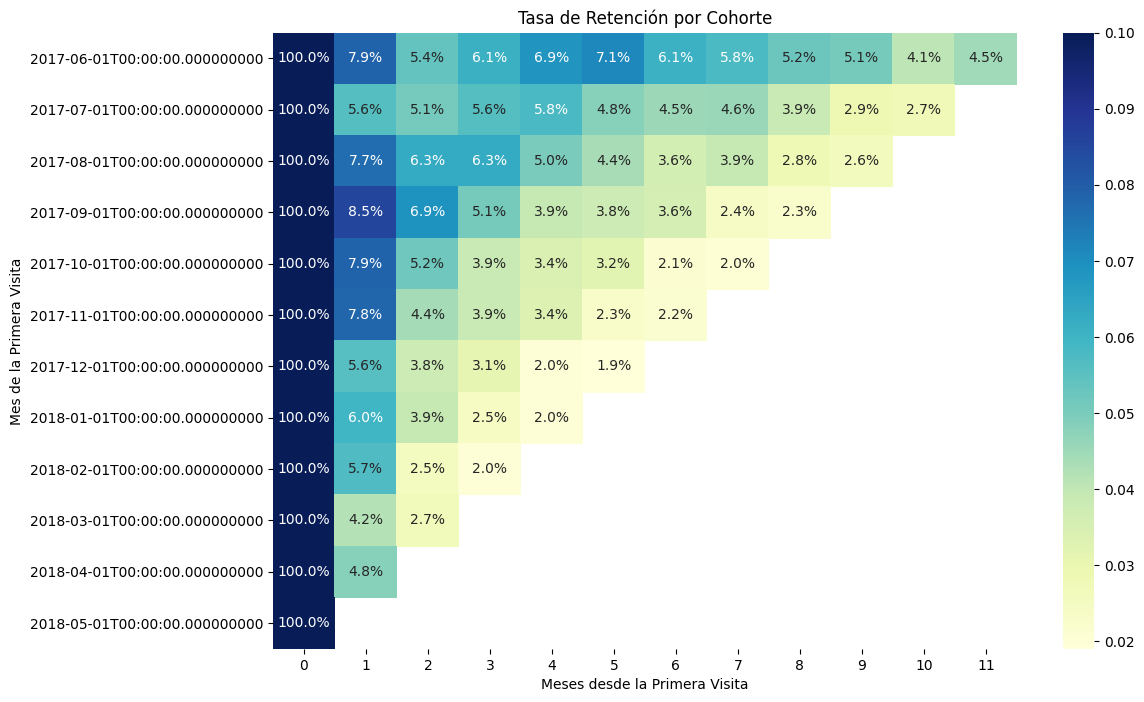

In [14]:
# Calcular la Tasa de Retención (RR) y crear un mapa de calor:
retention = cohorts.divide(cohorts[0], axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".1%", cmap="YlGnBu", vmax = .1)
plt.title('Tasa de Retención por Cohorte')
plt.xlabel('Meses desde la Primera Visita')
plt.ylabel('Mes de la Primera Visita')
plt.show()

# Conclusiones sobre los resultados de las visitas

# 1. Uso Diario, semanal y mensual
Mensual: Los datos muestran la cantidad de personas que usan el servicio cada mes durante un año. Observamos que el uso mensual varía significativamente, con un mínimo de 11,631 usuarios en agosto de 2017 y un máximo de 32,797 usuarios en noviembre de 2017. Hay un aumento considerable en el número de usuarios de septiembre a diciembre de 2017, seguido de una disminución gradual hasta mayo de 2018.

Diario: El número de sesiones por día también varía ampliamente, los días con mayor actividad parecen ser los finales de mes, con el 31 de mayo de 2018 registrando 2,256 sesiones. Los días con menos actividad registran menos de 500 sesiones.

Semanal: Para calcular el uso semanal, se pueden agregar los datos diarios para obtener una media semanal. No obstante, los datos sugieren fluctuaciones significativas dependiendo del día de la semana, con posibles patrones de mayor uso al inicio y final de la semana laboral.

# 2. Duración de las sesiones
La duración promedio de cada sesión es de aproximadamente 643.5 segundos, lo que equivale a alrededor de 10.7 minutos. Esto indica que los usuarios pasan un tiempo significativo en cada sesión, lo cual es una buena señal de compromiso.

# 3. Frecuencia de regreso de los usuarios
La frecuencia con la que los usuarios regresan al servicio se distribuye de la siguiente manera:

- La mayoría de los usuarios (183,124) solo utilizan el servicio una vez.
- Hay un número considerable de usuarios (27,591) que regresan por segunda vez.
- Un número mucho menor de usuarios regresa tres o más veces, con la frecuencia disminuyendo exponencialmente.

Esto sugiere que mientras el servicio es probado por muchos usuarios, solo una fracción decide regresar varias veces, lo que podría indicar una necesidad de mejorar la retención de usuarios.

# Resumen
El uso del servicio varía significativamente de un mes a otro y también a nivel diario, la duración media de la sesión es razonablemente alta, lo que indica que los usuarios que acceden al servicio tienden a pasar un tiempo considerable en él. Aunque muchos usuarios prueban el servicio, solo una minoría regresa para usarlo repetidamente, lo que sugiere una oportunidad para mejorar la retención de usuarios.

# Recomendaciones
Investigar las causas de las variaciones mensuales y diarias en el uso, considerando factores como campañas de marketing, eventos especiales, o cambios en la funcionalidad del servicio. Implementar estrategias para mejorar la retención de usuarios, como programas de fidelización, mejoras en la experiencia del usuario, y análisis de feedback para identificar áreas de mejora.
Continuar optimizando la plataforma para mantener y posiblemente aumentar la duración de las sesiones, asegurando que los usuarios encuentren valor durante su tiempo en el servicio.

# Ventas

In [15]:
# ¿Cuándo la gente empieza a comprar?

# Crear nuevas columnas para día, semana y mes
orders['day'] = orders['buy_ts'].dt.date
orders['week'] = orders['buy_ts'].dt.to_period('W').apply(lambda r: r.start_time)
orders['month'] = orders['buy_ts'].dt.to_period('M').apply(lambda r: r.start_time)

# Calcular el tiempo entre el registro (primera visita) y la primera compra
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_purchase = orders.groupby('uid').agg({'buy_ts':'min'}).reset_index()
first_purchase.columns = ['uid', 'first_purchase_ts']

# Merge de datos
user_data = pd.merge(first_visit, first_purchase, on='uid', how='inner')
user_data['time_to_first_purchase'] = (user_data['first_purchase_ts'] - user_data['start_ts']).dt.days
user_data['first_visit_month'] = user_data['start_ts'].dt.to_period('M').dt.start_time
user_data['first_order_month'] = user_data['first_purchase_ts'].dt.to_period('M').dt.start_time

# Calcular la distribución de conversiones
conversion_distribution = user_data['time_to_first_purchase'].value_counts().sort_index()

# Mostrar resultados
conversion_distribution

0      26363
1       1011
2        563
3        434
4        324
       ...  
354        1
355        3
357        4
362        1
363        1
Name: time_to_first_purchase, Length: 345, dtype: int64

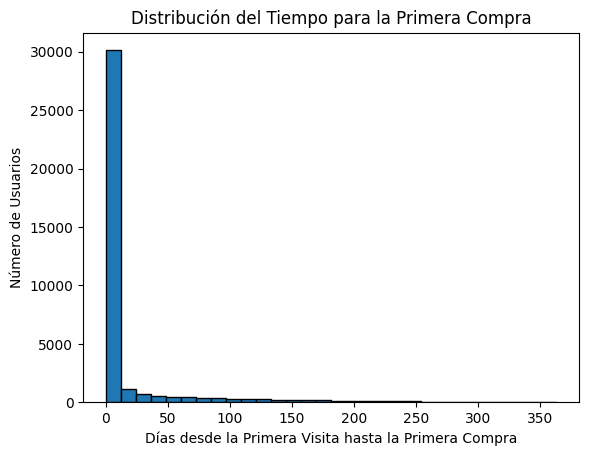

In [16]:
# ¿Cuántos pedidos hacen durante un período de tiempo dado?

# Calcular el tiempo en días entre la primera visita y la primera compra
user_data['time_to_first_purchase'] = (user_data['first_purchase_ts'] - user_data['start_ts']).dt.days

# Graficar la distribución del tiempo entre la primera visita y la primera compra
plt.hist(user_data['time_to_first_purchase'], bins=30, edgecolor='black')
plt.title('Distribución del Tiempo para la Primera Compra')
plt.xlabel('Días desde la Primera Visita hasta la Primera Compra')
plt.ylabel('Número de Usuarios')
plt.show()

In [17]:
# ¿Cuál es el tamaño promedio de compra?

# Calcular el tamaño de los cohortes
cohort_sizes = user_data.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'cohort_size']

# Unir orders con user_data para crear orders_full
orders_full = pd.merge(orders, user_data[['uid', 'first_order_month']], on='uid', how='left')

# Calcular el número de compras por cohorte y mes de compra
cohorts = orders_full.groupby(['first_order_month', 'month']).agg({'uid': 'count'}).reset_index()
cohorts.columns = ['first_order_month', 'month', 'num_orders']

# Calcular la edad del cohorte en meses
cohorts['age_month'] = ((cohorts['month'] - cohorts['first_order_month']) / np.timedelta64(1, 'M')).round().astype(int)

# Unir cohorts con cohort_sizes para obtener el número de compras por usuario
cohorts = pd.merge(cohorts, cohort_sizes, on='first_order_month')
cohorts['orders_per_buyer'] = cohorts['num_orders'] / cohorts['cohort_size']

# Crear la tabla de doble entrada (cohortes report)
cohorts_report = cohorts.pivot_table(
    index='first_order_month', 
    columns='age_month', 
    values='orders_per_buyer', 
    aggfunc='sum'
).cumsum(axis=1)

cohorts_report

age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,1.163618,1.251112,1.337123,1.448838,1.593178,1.700939,1.837370,1.923381,2.028176,2.103806,2.151261,2.193772
2017-07-01,1.136765,1.188768,1.251170,1.305252,1.342694,1.385335,1.417057,1.443058,1.473219,1.485699,1.513261,NaN
2017-08-01,1.118978,1.197810,1.270803,1.329927,1.391971,1.437226,1.472993,1.529927,1.563504,1.597080,NaN,NaN
2017-09-01,1.136381,1.221232,1.283611,1.347152,1.373111,1.415343,1.457187,1.478884,1.502518,NaN,NaN,NaN
2017-10-01,1.143779,1.216129,1.253456,1.281567,1.311290,1.335023,1.354839,1.383641,NaN,NaN,NaN,NaN
2017-11-01,1.179368,1.276648,1.321245,1.372948,1.406273,1.420730,1.445724,NaN,NaN,NaN,NaN,NaN
2017-12-01,1.152635,1.214237,1.260324,1.301164,1.320785,1.344741,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,1.121554,1.187963,1.235102,1.254076,1.277201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,1.121611,1.182416,1.205149,1.224322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


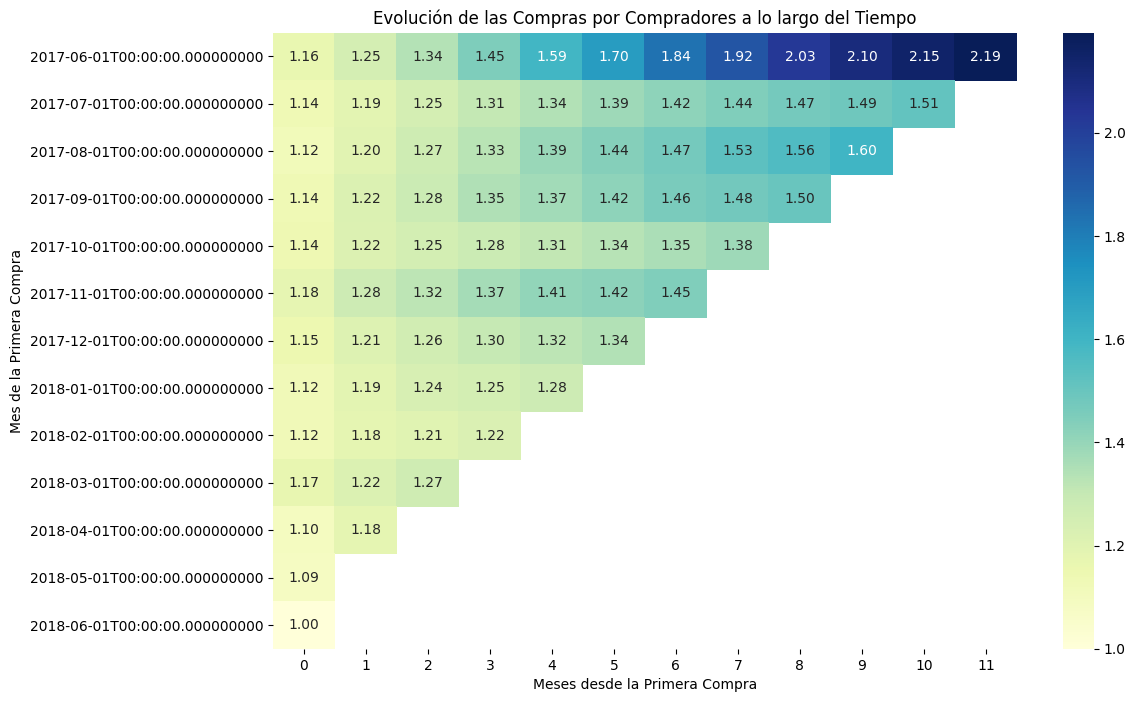

In [18]:
# # Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(cohorts_report, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Evolución de las Compras por Compradores a lo largo del Tiempo')
plt.xlabel('Meses desde la Primera Compra')
plt.ylabel('Mes de la Primera Compra')
plt.show()

In [19]:
# ¿Cuánto dinero traen? (LTV)

# Calcular el revenue total por cohorte y mes de compra
cohorts_revenue = orders_full.groupby(['first_order_month', 'month']).agg({'revenue': 'sum'}).reset_index()
cohorts_revenue.columns = ['first_order_month', 'month', 'total_revenue']

# Calcular la edad del cohorte en meses
cohorts_revenue['age_month'] = ((cohorts_revenue['month'] - cohorts_revenue['first_order_month']) / np.timedelta64(1, 'M')).round().astype(int)

# Unir cohorts_revenue con cohort_sizes para obtener el tamaño del cohorte
cohorts_ltv = pd.merge(cohorts_revenue, cohort_sizes, on='first_order_month')

# Calcular el LTV
cohorts_ltv['ltv'] = cohorts_ltv['total_revenue'] / cohorts_ltv['cohort_size']

cohorts_ltv['first_order_month'] = cohorts_ltv['first_order_month'].dt.date


In [20]:

# Crear la tabla de doble entrada para el LTV
cohorts_ltv_report = cohorts_ltv.pivot_table(
    index='first_order_month', 
    columns='age_month', 
    values='ltv', 
    aggfunc='sum'
).cumsum(axis=1)

cohorts_ltv_report

age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,4.724414,5.209743,5.647380,6.602051,7.624582,8.360084,9.310524,9.892116,10.445329,11.051117,11.622378,11.879234
2017-07-01,6.010218,6.345429,6.968960,7.327936,7.504727,7.660775,7.780983,7.922803,8.084035,8.231180,8.386854,NaN
2017-08-01,5.276518,5.748511,6.206993,6.598270,7.092321,7.375861,7.586526,7.991533,8.283745,8.471723,NaN,NaN
2017-09-01,5.644529,6.762115,7.283045,11.258838,11.659396,12.306463,13.008071,13.251220,13.435227,NaN,NaN,NaN
2017-10-01,5.003733,5.539495,5.730889,5.888035,6.039594,6.159956,6.244772,6.360242,NaN,NaN,NaN,NaN
2017-11-01,5.154683,5.553916,5.753472,6.078424,6.226437,6.280316,6.395244,NaN,NaN,NaN,NaN,NaN
2017-12-01,4.738191,4.998565,5.923662,6.988937,7.301866,7.639913,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,4.135636,4.430394,4.734675,4.877453,4.940151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,4.156987,4.435262,4.513777,4.587921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


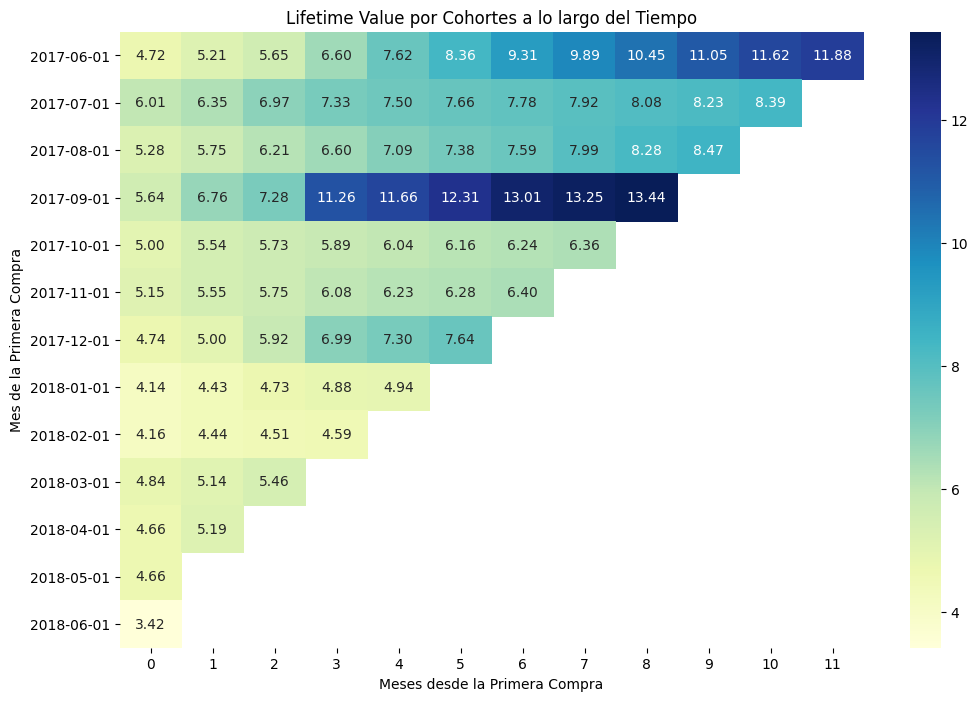

In [21]:
# Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(cohorts_ltv_report, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Lifetime Value por Cohortes a lo largo del Tiempo')
plt.xlabel('Meses desde la Primera Compra')
plt.ylabel('Mes de la Primera Compra')
plt.show()

# Conclusiones sobre los resultados de las ventas

# 1. Cuándo la gente epieza a comprar
El tiempo que toma para que la gente haga su primera compra varía:

- Inmediatamente (0 días): La gran mayoría (26,363 usuarios) realiza su primera compra el mismo día que se registra.
- Posteriormente: Un número menor de usuarios realiza su primera compra después de un día (1,011), y este número disminuye con el tiempo, mostrando una tendencia decreciente con algunos usuarios tomando hasta un año para hacer su primera compra.

# 2. Cantidad de pedidos durante un período de tiempo dado
La cantidad de pedidos que los usuarios hacen en un período determinado muestra una distribución sesgada: En promedio, los usuarios hacen alrededor de 1.38 pedidos, la mayoría de los usuarios hacen solo un pedido (mediana y percentiles 25% y 75% son 1). Sin embargo, hay algunos usuarios que hacen un número muy alto de pedidos, con un máximo de 239 pedidos registrados.

# 3. Tamaño promedio de compra
El tamaño promedio de cada compra es aproximadamente 5 unidades. Esto indica que, en cada transacción, los usuarios compran en promedio 5 productos o servicios.

# 4. Valor de vida del cliente (LTV)
El valor total que los usuarios aportan (Lifetime Value, LTV) presenta una distribución altamente asimétrica: En promedio, cada usuario genera aproximadamente 6.90 en ingresos, la mayoría de los usuarios generan ingresos bajos, con un 25% generando hasta 1.47 y un 50% hasta 3.05. El 75% genera hasta 5.80. Sin embargo, hay valores atípicos significativos, con un máximo de ingresos de 11,810.18.

# Resumen y recomendaciones
La mayoría de los usuarios que compran lo hacen inmediatamente. Esto sugiere que el proceso de conversión inicial es efectivo, pero también hay margen para aumentar las conversiones que tardan más en realizarse, aunque la mayoría de los usuarios hacen solo un pedido, hay un pequeño grupo de usuarios que realizan muchos pedidos. Se podría explorar quiénes son estos usuarios y qué los motiva a realizar tantas compras, para tratar de replicar este comportamiento en otros usuarios.

Con un tamaño promedio de compra de 5 unidades, se podrían desarrollar estrategias de venta cruzada (cross-selling) y de aumento del tamaño de la cesta (upselling) para aumentar el tamaño promedio de las compras.

Dado que el LTV varía significativamente y hay una gran cantidad de ingresos generados por unos pocos usuarios, se deben implementar estrategias de fidelización para mantener y aumentar el valor de estos usuarios de alto valor, así como técnicas para incrementar el LTV de los usuarios con menor aportación.

# Estrategias adicionales
Dividir a los usuarios en segmentos basados en su comportamiento de compra y adaptar las estrategias de marketing para cada segmento, implementar campañas de retargeting para usuarios que se registraron pero no realizaron una compra inmediata, desarrollar programas de lealtad para incentivar a los usuarios a realizar más pedidos y aumentar su LTV  e investigar las razones por las que algunos usuarios tardan en realizar su primera compra y buscar soluciones para reducir este tiempo.

Estas conclusiones y estrategias pueden ayudar a optimizar el proceso de conversión, aumentar el tamaño promedio de las compras y maximizar el valor de vida de los clientes.

# Marketing 

In [22]:
# ¿Cuánto dinero se gastó? (Total/por fuente de adquisición/a lo largo del tiempo)

# Gastos totales
total_costs = costs['costs'].sum()

# Gastos por fuente
costs_by_source = costs.groupby('source_id')['costs'].sum()

# Gastos a lo largo del tiempo
costs_over_time = costs.groupby('dt')['costs'].sum()

# Mostrar resultados
display(total_costs)
display(costs_by_source)
display(costs_over_time)

329131.62

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

dt
2017-06-01     735.26
2017-06-02     721.19
2017-06-03     450.85
2017-06-04     761.16
2017-06-05     821.44
               ...   
2018-05-27     532.87
2018-05-28     619.44
2018-05-29     784.79
2018-05-30    1183.00
2018-05-31    2153.70
Name: costs, Length: 364, dtype: float64

In [23]:
# ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

# Calcular número de clientes adquiridos por fuente
acquisitions_by_source = visits.groupby('source_id')['uid'].nunique()

# Calcular el costo de adquisición por cliente (CAC) por fuente
cac_by_source = costs_by_source / acquisitions_by_source

# Mostrar resultados
cac_by_source

source_id
1     1.096546
2     1.631017
3     1.890439
4     0.731201
5     0.908434
6          NaN
7          NaN
9     0.595584
10    0.721766
dtype: float64

In [24]:
# ¿Cuán rentables eran las inversiones? (ROMI)

# Calcular ingresos totales por fuente de adquisición
revenue_by_source = orders.merge(visits[['uid', 'source_id']], on='uid', how='left')
revenue_by_source = revenue_by_source.groupby('source_id')['revenue'].sum()

# Calcular ROMI por fuente de adquisición
romi_by_source = (revenue_by_source - costs_by_source) / costs_by_source

# Mostrar resultados
romi_by_source

source_id
1     109.313944
2      60.631237
3       1.099381
4       7.132649
5      21.827344
7            NaN
9       5.586736
10      1.510821
dtype: float64

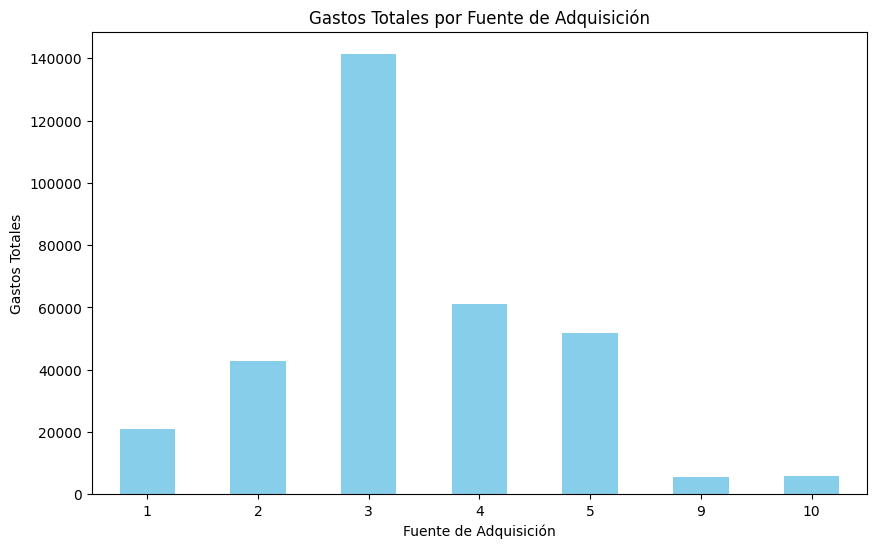

In [25]:
# Gráfico de gastos totales por fuente
plt.figure(figsize=(10, 6))
costs_by_source.plot(kind='bar', color='skyblue')
plt.title('Gastos Totales por Fuente de Adquisición')
plt.xlabel('Fuente de Adquisición')
plt.ylabel('Gastos Totales')
plt.xticks(rotation=0)
plt.show()

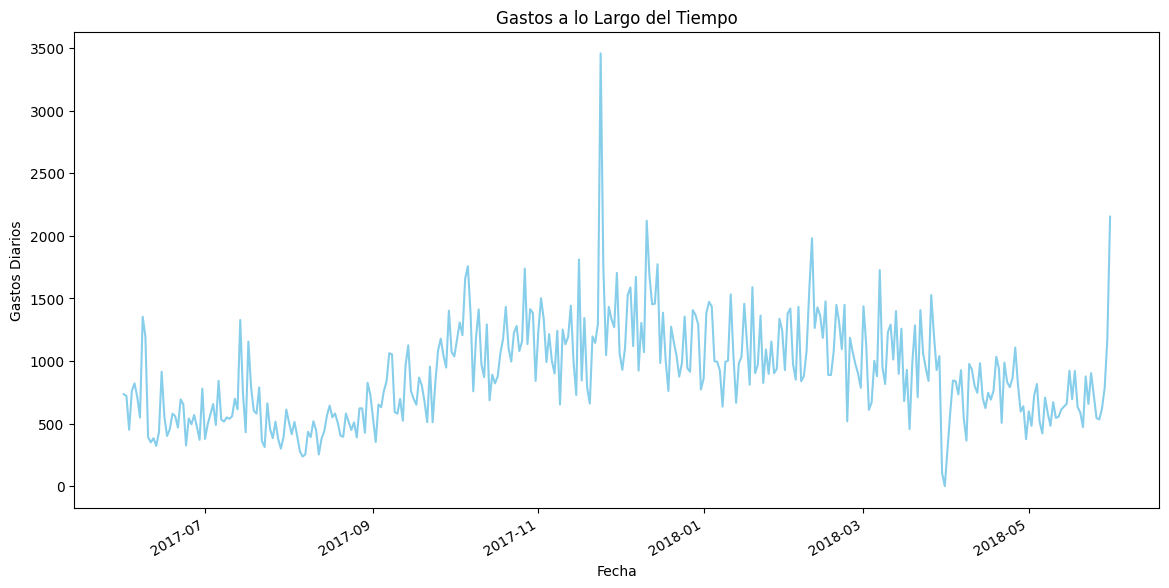

In [26]:
# Gráfico de gastos a lo largo del tiempo
plt.figure(figsize=(14, 7))
costs_over_time.plot(color='skyblue')
plt.title('Gastos a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Gastos Diarios')
plt.show()

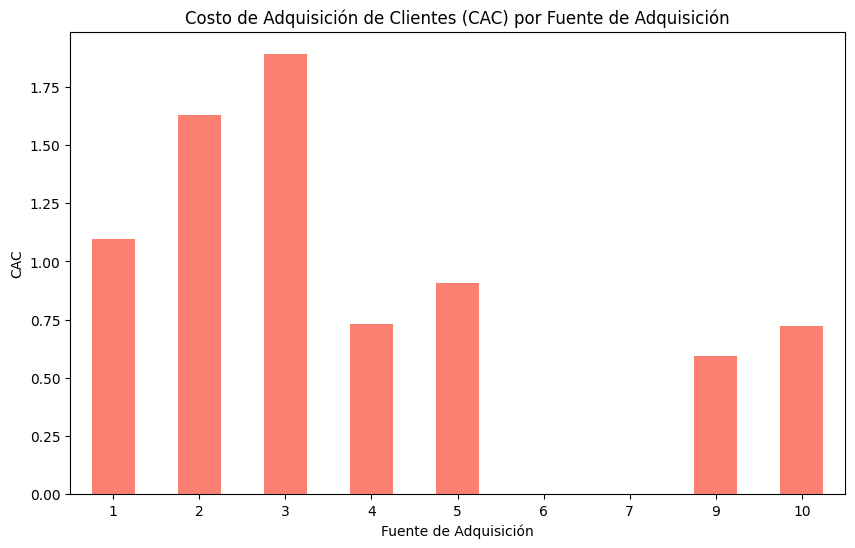

In [27]:
# Gráfico de CAC por fuente de adquisición
plt.figure(figsize=(10, 6))
cac_by_source.plot(kind='bar', color='salmon')
plt.title('Costo de Adquisición de Clientes (CAC) por Fuente de Adquisición')
plt.xlabel('Fuente de Adquisición')
plt.ylabel('CAC')
plt.xticks(rotation=0)
plt.show()

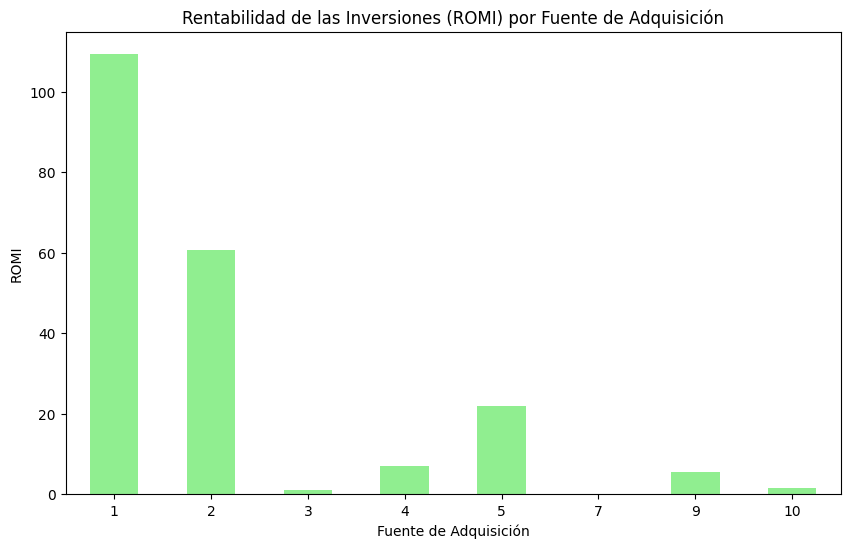

In [28]:
# Gráfico de ROMI por fuente de adquisición
plt.figure(figsize=(10, 6))
romi_by_source.plot(kind='bar', color='lightgreen')
plt.title('Rentabilidad de las Inversiones (ROMI) por Fuente de Adquisición')
plt.xlabel('Fuente de Adquisición')
plt.ylabel('ROMI')
plt.xticks(rotation=0)
plt.show()

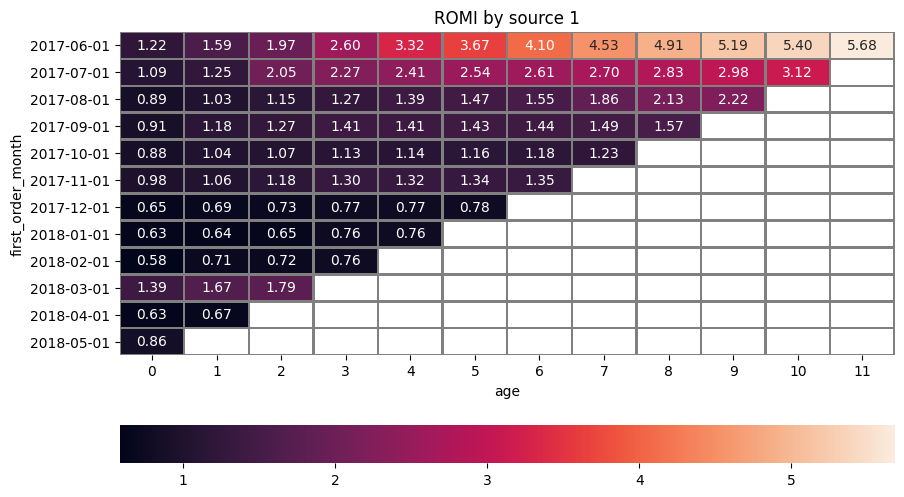

In [29]:
# Crear la tabla de los usuarios únicos para obtener el source id de por el que fue adquirido cada uno de ellos
# Esta tabla tarda bastante para crearse debido a las limitaciones de memoria que tenemos, así que si harás pruebas recomiendo
# crearla en una celda aparte para no tener que recalcularla múltiples veces
users = visits.sort_values('start_ts').groupby('uid').first()
users = users[['source_id']]

# Unir esta información con tu tabla user data
user_data = pd.merge(user_data, users, left_on='uid', right_index=True)

# Calculamos el revenue de las compras por usuario en cada uno de los meses
month_revenue = orders.groupby(['uid', 'month']).agg({'revenue': 'sum'}).reset_index()

# Volvemos a unir esta información en la tabla user_data y de esta forma ya contamos con una tabla que contiene el mes de
# la primera compra de cada usuario, el source por el cual entraron a la página y el revenue de los usuarios en cada uno de 
# los meses. 
user_data = user_data.merge(month_revenue,on = 'uid')

# Filtramos por la fuente 1 para hacer el ejemplo
source_1 = user_data[user_data['source_id'] == 1]

# Ya que primero tenemos que calcular el LTV antes de calcular el ROMI, debemos usar una vez más la tabla cohort_sizes
cohort_sizes_t = (
    source_1.groupby(['source_id', 'first_order_month'])
    .agg({'uid': 'nunique'})
    .reset_index()
    )
cohort_sizes_t.columns = ['source_id', 'first_order_month', 'n_buyers']

# Creamos una tabla calculando el revenue de los cohortes agrupando por la fuente, mes de primera compra y mes de compra
# a este revenue que es el gross product lo nombramos gp
cohorts_revenue_t = (
    source_1.groupby(['source_id', 'first_order_month', 'month'])
    .agg({'revenue': 'sum'})
    .reset_index()
    )
cohorts_revenue_t.columns = ['source_id', 'first_order_month', 'month', 'gp']

# Incluímos los tamaños de los cohortes a la tabla
report_romi = pd.merge(cohort_sizes_t, cohorts_revenue_t, on=['source_id', 'first_order_month'])

# Calculamos la edad de los cohortes de la misma forma que en incisos anteriores
report_romi['age'] = (
    report_romi['month'] - report_romi['first_order_month']
    ) / np.timedelta64(1, 'M')
report_romi['age'] = report_romi['age'].round().astype('int')

# Calculamos el LTV dividiendo el gross product entre el número de compradores
report_romi['ltv'] = report_romi['gp'] / report_romi['n_buyers']
report_romi

# Ahora vamos a incorporar los costos de adquisición al análisis, así que obtenemos la tabla de los costos por mes
costs['costs_month'] = costs['dt'].values.astype('datetime64[M]')
costs_by_month = costs.groupby(['source_id', 'costs_month']).agg({'costs': 'sum'}).reset_index()

# Agregamos los costos por mes en nuestra tabla del LTV 
report_romi = pd.merge(report_romi, costs_by_month,
                       left_on=['source_id', 'first_order_month'], right_on=['source_id', 'costs_month'])
report_romi = report_romi.drop(['costs_month'], axis = 1) 

# Calculamos el CAC dividiendo los costos por mes entre el número de usuarios
report_romi['cac'] = report_romi['costs'] / report_romi['n_buyers']

# Finalmente calculamos el ROMI haciendo la división entre el LTV y el CAC
report_romi['romi'] = report_romi['ltv'] / report_romi['cac']        

# Ya solo falta pivotear la tabla y hacer el mapa de calor 
romi = report_romi.pivot_table(index='first_order_month', columns='age', values='romi', aggfunc='mean')\
.cumsum(axis=1)
romi.round(2).fillna('')

plt.figure(figsize=(10, 6))
romi.index=romi.index.astype(str)
sns.heatmap(romi, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'} 
        ).set(title ='ROMI by source {}'.format(1))
plt.show()

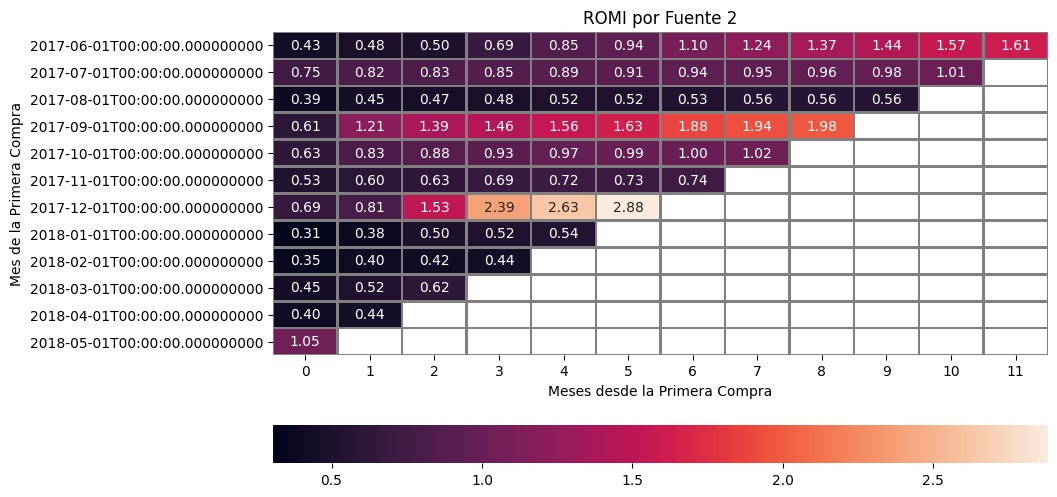

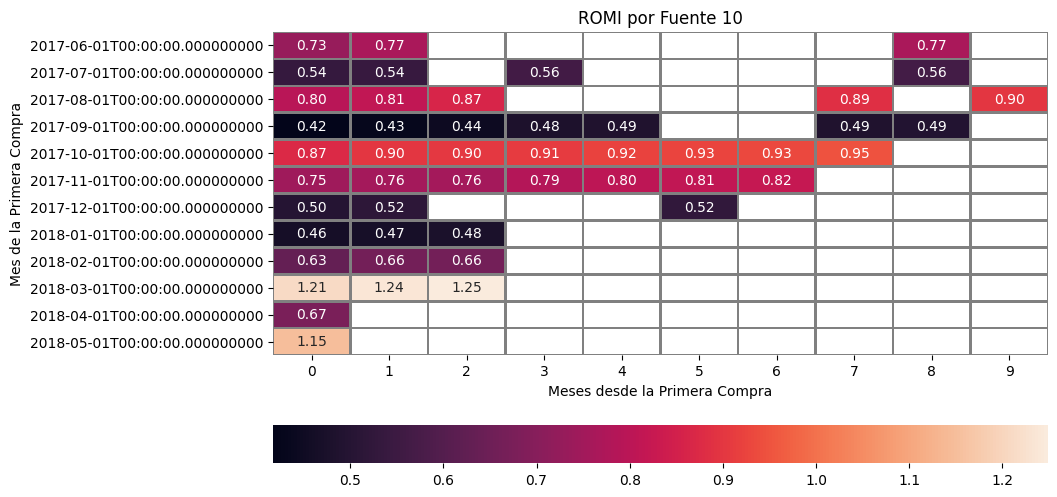

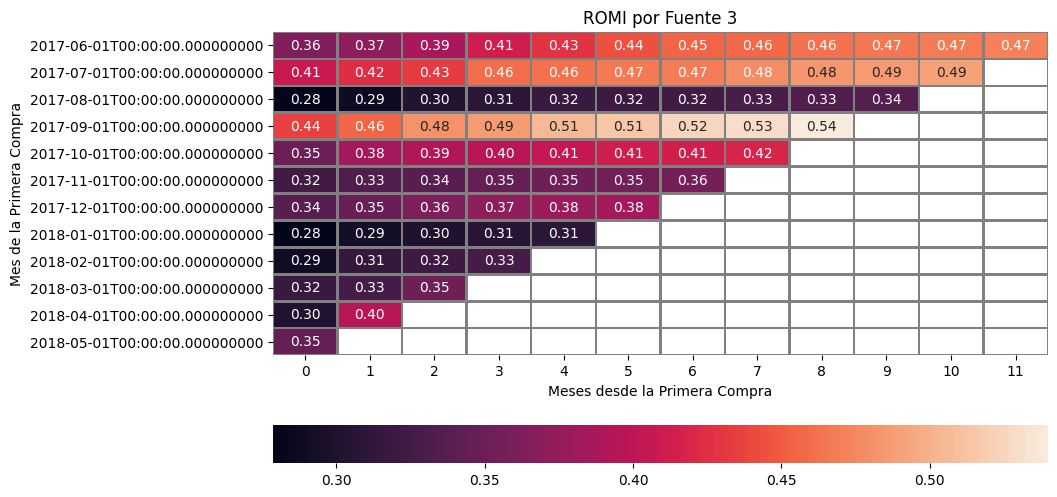

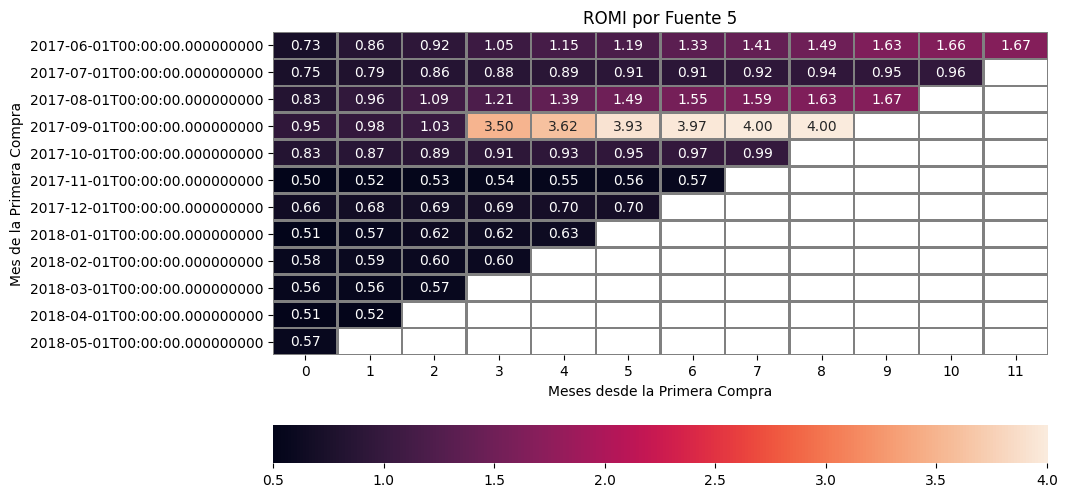

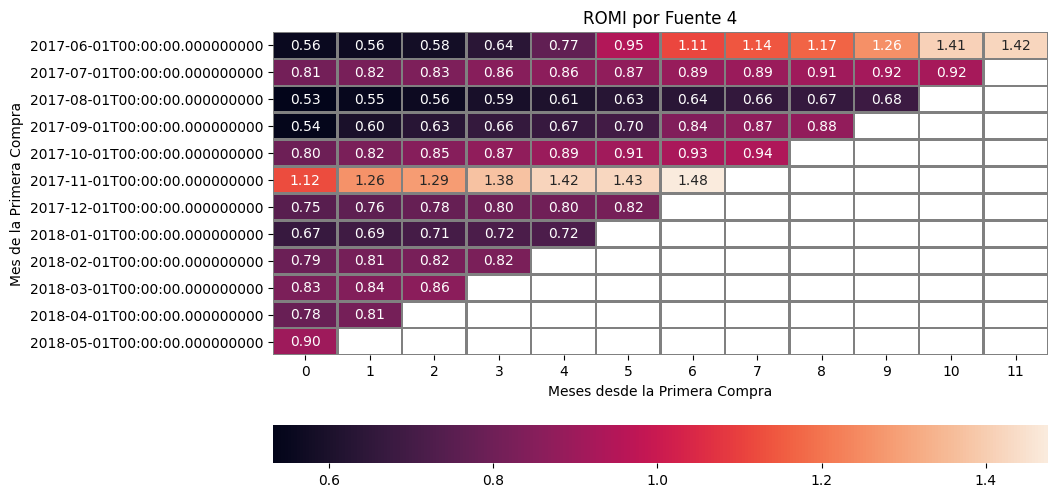

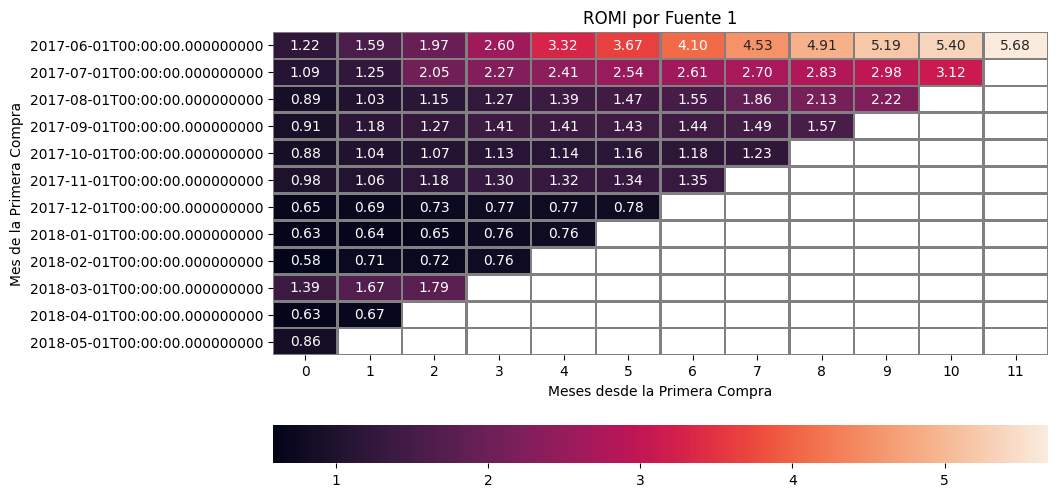

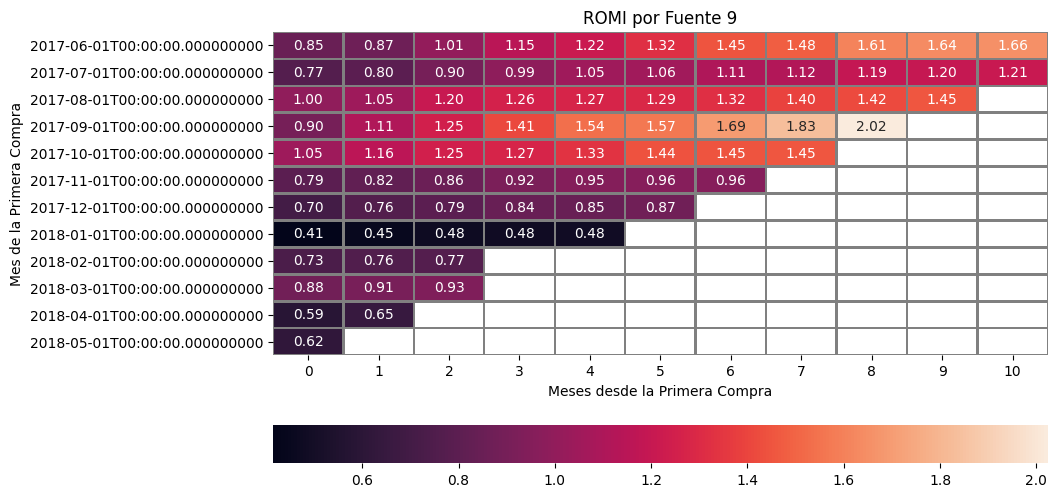

No hay datos suficientes para graficar el ROMI de la fuente 7


In [30]:
# 1. Obtener los source_id únicos (o seleccionar los 10 primeros)
sources_to_analyze = user_data['source_id'].unique()[:10]  # Tomamos los primeros 10 source_id únicos

# 2. Crear un diccionario para almacenar los resultados de ROMI
romi_results = {}

# 3. Iniciar el bucle para iterar sobre cada fuente de adquisición
for source in sources_to_analyze:
    
    # Filtrar datos para la fuente de adquisición actual
    source_data = user_data[user_data['source_id'] == source]

    # Calcular el tamaño de la cohorte
    cohort_sizes_t = source_data.groupby(['source_id', 'first_order_month']).agg({'uid': 'nunique'}).reset_index()
    cohort_sizes_t.columns = ['source_id', 'first_order_month', 'n_buyers']

    # Calcular los ingresos de cada cohorte por mes
    cohorts_revenue_t = source_data.groupby(['source_id', 'first_order_month', 'month']).agg({'revenue': 'sum'}).reset_index()
    cohorts_revenue_t.columns = ['source_id', 'first_order_month', 'month', 'gp']

    # Combinar el tamaño de la cohorte con los ingresos
    report_romi = pd.merge(cohort_sizes_t, cohorts_revenue_t, on=['source_id', 'first_order_month'])

    # Calcular la edad de las cohortes
    report_romi['age'] = (report_romi['month'] - report_romi['first_order_month']) / np.timedelta64(1, 'M')
    report_romi['age'] = report_romi['age'].round().astype(int)

    # Calcular el LTV
    report_romi['ltv'] = report_romi['gp'] / report_romi['n_buyers']

    # Obtener los costos de adquisición por mes y fuente
    costs['costs_month'] = costs['dt'].values.astype('datetime64[M]')
    costs_by_month = costs.groupby(['source_id', 'costs_month']).agg({'costs': 'sum'}).reset_index()

    # Incorporar los costos en el análisis
    report_romi = pd.merge(report_romi, costs_by_month, left_on=['source_id', 'first_order_month'], right_on=['source_id', 'costs_month'])
    report_romi = report_romi.drop(['costs_month'], axis=1)

    # Calcular el CAC
    report_romi['cac'] = report_romi['costs'] / report_romi['n_buyers']

    # Calcular el ROMI
    report_romi['romi'] = report_romi['ltv'] / report_romi['cac']

    # Crear el mapa de calor del ROMI acumulado
    romi = report_romi.pivot_table(index='first_order_month', columns='age', values='romi', aggfunc='mean').cumsum(axis=1)
    
    # Asegurarse de que todos los valores son numéricos y verificar que no esté vacío
    romi = romi.replace('', np.nan).astype(float)
    
    # Solo graficar si hay datos válidos
    if not romi.empty and romi.notna().sum().sum() > 0:
        # Guardar los resultados en el diccionario
        romi_results[source] = romi

        # Mostrar el mapa de calor
        plt.figure(figsize=(10, 6))
        sns.heatmap(romi, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws={'orientation': 'horizontal'})
        plt.title(f'ROMI por Fuente {source}'.format(1))
        plt.xlabel('Meses desde la Primera Compra')
        plt.ylabel('Mes de la Primera Compra')
        plt.show()
    else:
        print(f"No hay datos suficientes para graficar el ROMI de la fuente {source}")

# Conclusiones sobre los resultados del Marketing

# 1. Gasto total y por fuente de adquisición
El gasto total en todas las fuentes de adquisición es de 329,131.62, las fuentes de adquisición con mayor gasto fueron la fuente 3 con 141,321.63 y la fuente 4 con 61,073.60. 

Las fuentes de adquisición con menor gasto fueron la fuente 9 con 5,517.49 y la fuente 10 con 5,822.49.

# 2. Gasto a lo largo del tiempo
El gasto diario varía significativamente, con picos y valles notables, algunos días tienen un gasto muy alto, como el 31 de mayo de 2018 con 2,153.70. Los gastos parecen ser constantes en general, con algunos picos esporádicos.

# 3. Costo de adquisición de clientes (CAC) por fuente
El Costo de Adquisición de Clientes (CAC) varía según la fuente de adquisición:

- La fuente con el menor CAC es la fuente 9 con 0.595584.
- La fuente con el mayor CAC es la fuente 3 con 1.890439.

# 4. Rentabilidad de las inversiones (ROMI)
El Retorno sobre la Inversión en Marketing (ROMI) también varía significativamente:

- La fuente más rentable es la fuente 1 con un ROMI de 109.313944.
- La fuente menos rentable es la fuente 3 con un ROMI de 1.099381.
- Las fuentes 6 y 7 no tienen datos suficientes para calcular el ROMI.

# Resumen y recomendaciones
Considerar reducir el gasto en fuentes menos rentables como la fuente 3, a pesar de su alto gasto total, dado su bajo ROMI. Reasignar presupuesto a fuentes con mejor rendimiento, como las fuentes 1 y 5, que tienen ROMI altos.

Realizar un monitoreo continuo del gasto diario para identificar patrones y ajustar estrategias en tiempo real, investigar los días con altos picos de gasto para entender las causas y replicar las acciones que resultaron en esos picos si fueron exitosas.

# Análisis de CAC y ROMI
Focalizar las inversiones en fuentes con bajo CAC y alto ROMI, como la fuente 1, para maximizar la eficiencia del presupuesto.
Evaluar el rendimiento de las fuentes 6 y 7 para determinar si se deben continuar utilizando o no.

# Estrategias de retención y conversión
Implementar estrategias para mejorar la conversión y retención de clientes adquiridos a través de las fuentes con alto CAC, para mejorar su ROMI, analizar el perfil de los clientes provenientes de las fuentes más rentables para entender qué los hace valiosos y cómo atraer más de estos clientes.

Desarrollar campañas específicas para fuentes con bajo rendimiento para mejorar su ROMI, considerar campañas de remarketing para fuentes con buenos resultados iniciales pero bajo ROMI.

Revisar periódicamente el presupuesto asignado a cada fuente de adquisición para ajustarlo basado en el rendimiento medido por CAC y ROMI.

Estas conclusiones y recomendaciones pueden ayudar a optimizar las inversiones en marketing, mejorar la eficiencia del gasto y maximizar la rentabilidad de las campañas de adquisición de clientes.

## Paso. Conclusión General del Análisis

Este proyecto se centró en analizar y optimizar diversas métricas clave relacionadas con el comportamiento de los usuarios, las transacciones y las estrategias de adquisición de clientes. A continuación se presenta un resumen de las principales conclusiones y recomendaciones extraídas de los análisis realizados:

# 1. Comportamiento de los usuarios
El número de usuarios que utilizan el servicio varía significativamente mes a mes, con picos notables en los últimos meses del año y una disminución gradual después.

Las sesiones diarias muestran una variabilidad considerable, con ciertos días presentando un uso mucho más alto que otros. la duración promedio de cada sesión es de aproximadamente 10.7 minutos, indicando un buen nivel de compromiso.

Una gran mayoría de usuarios (183,124) solo utilizan el servicio una vez, mientras que solo una minoría regresa múltiples veces, esto sugiere una oportunidad para mejorar la retención de usuarios y fomentar el uso repetido.

# 2. Transacciones y compras
La mayoría de las primeras compras ocurren el mismo día del registro, pero hay un número decreciente de usuarios que realizan su primera compra en los días y meses siguientes, la mayoría de los usuarios hacen solo un pedido, pero algunos realizan un número significativamente mayor de pedidos.

El tamaño promedio de compra es de 5 unidades. El valor de vida del cliente (LTV) muestra una alta variabilidad, con un promedio de 6.90 y valores atípicos significativos.

# 3. Estrategias de adquisición de clientes
- El gasto total en todas las fuentes de adquisición es de 329,131.62, con la fuente 3 siendo la más costosa.
- El gasto diario muestra picos y valles, indicando variaciones significativas a lo largo del tiempo.

La fuente con el menor CAC es la fuente 9, mientras que la fuente 3 tiene el mayor CAC, esto sugiere la necesidad de optimizar las estrategias de adquisición en función del costo y el rendimiento.

# Rentabilidad de las inversiones (ROMI):

- La fuente más rentable es la fuente 1, mientras que la fuente 3 es la menos rentable.
- Las fuentes sin datos suficientes deben ser evaluadas para determinar su viabilidad.

# Recomendaciones
- Implementar programas de fidelización y estrategias de engagement para aumentar la frecuencia de uso y la retención de usuarios.
- Analizar el comportamiento de los usuarios recurrentes para identificar factores clave de retención.
- Desarrollar estrategias de venta cruzada y upselling para aumentar el tamaño promedio de las compras.
- Realizar análisis de abandono del carrito para reducir el tiempo a la primera compra.

# Ajuste de presupuesto de marketing:

Reasignar presupuesto a fuentes con bajo CAC y alto ROMI, y reducir el gasto en fuentes menos rentables, monitorear y ajustar continuamente las estrategias de adquisición en función de los datos de rendimiento.

Mantener un monitoreo constante de las métricas clave para identificar patrones y ajustar estrategias en tiempo real.
Evaluar y mejorar continuamente las estrategias basadas en los resultados obtenidos.

# Estrategias futuras:
Segmentación y Personalización: Implementar estrategias de segmentación de usuarios para personalizar las campañas de marketing y mejorar la eficacia, utilizar análisis predictivo para identificar usuarios con alto potencial de valor y dirigir esfuerzos específicos hacia ellos.

Innovación en la Experiencia del Usuario: Mejorar la experiencia del usuario en la plataforma para aumentar el compromiso y la satisfacción, recopilar y analizar feedback de los usuarios para identificar áreas de mejora y realizar ajustes necesarios.

En resumen, este proyecto proporciona una base sólida para la toma de decisiones informadas y la optimización de las estrategias de adquisición y retención de clientes, con el objetivo final de maximizar la rentabilidad y el valor de vida del cliente.